In [1]:
import librosa

array, sampling_rate = librosa.load(librosa.ex('trumpet'))
print(array.shape, sampling_rate)
import IPython.display as ipd

ipd.Audio(array, rate=sampling_rate)


(117601,) 22050


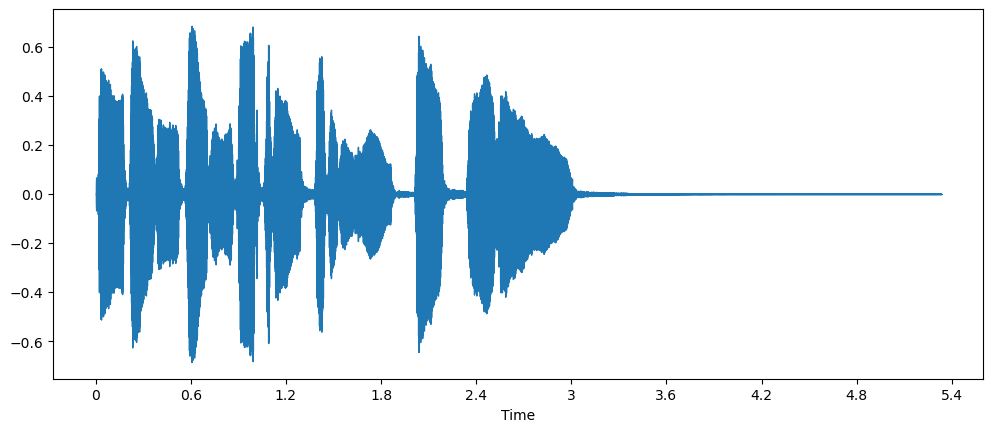

In [2]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)


(2049,) [ 8.43918495e-04+0.00000000e+00j -3.44816845e-04-3.07024772e-04j
  6.10497309e-05-9.10487281e-05j  1.01446705e-03-1.23013207e-03j
 -1.98504354e-03+2.04240725e-03j]


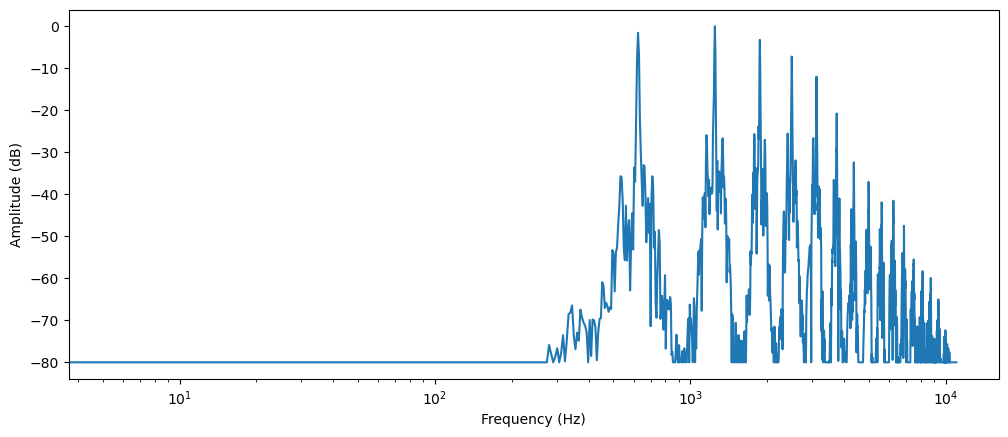

In [3]:
import numpy as np

dft_input = array[:4096]

# Calculate the DFT of the input
window = np.hanning(len(dft_input))
windowed_inputs = dft_input * window
dft = np.fft.rfft(windowed_inputs)

print(dft.shape, dft[:5])

amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=4096)

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")



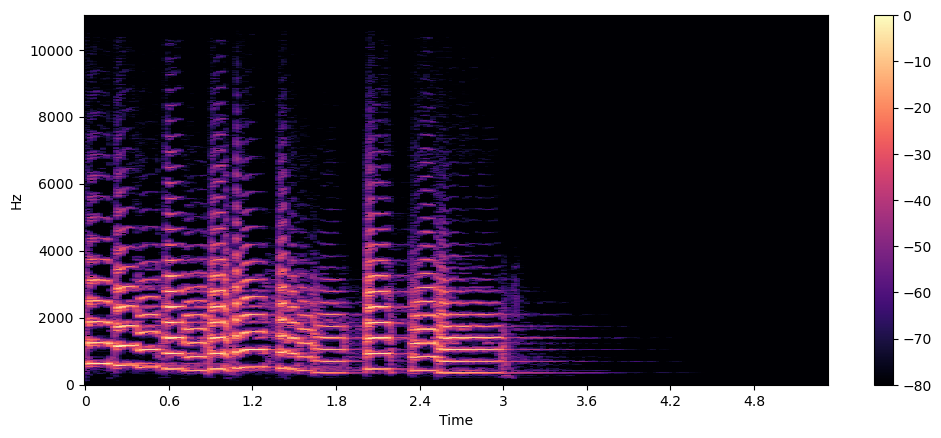

In [4]:
import numpy as np

D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()

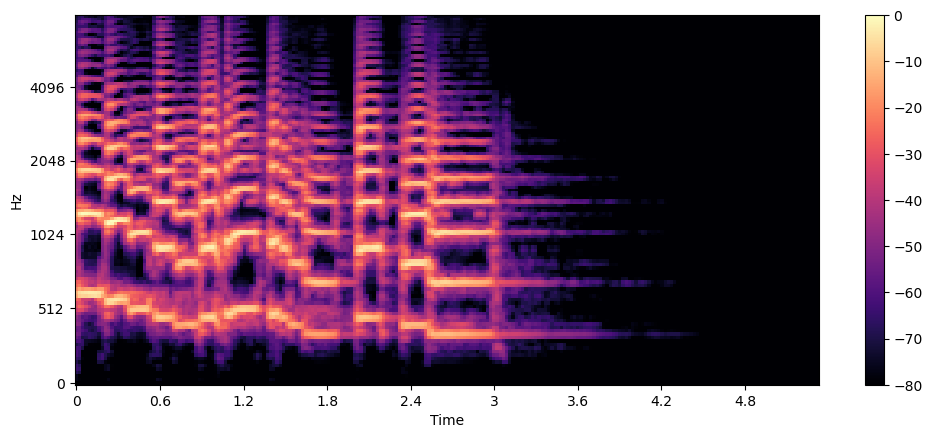

In [5]:
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar()

In [6]:
from datasets import load_dataset
minds = load_dataset("PolyAI/minds14", "en-US", split="train", trust_remote_code=True)
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 563
})

In [7]:
from IPython.display import Audio

example = minds[0]
first_audio = minds[0]["audio"]
display(Audio(first_audio["array"], rate=first_audio["sampling_rate"]))
minds[0]

id2label = minds.features["intent_class"].int2str
id2label(example["intent_class"])

columns_to_remove = ["lang_id", "english_transcription"]
minds = minds.remove_columns(columns_to_remove)
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 563
})

In [8]:
import gradio as gr

def generate_audio():
    example = minds.shuffle()[0]
    audio = example["audio"]
    return (
        audio["sampling_rate"],
        audio["array"],
    ), id2label(example["intent_class"])

with gr.Blocks() as demo:
    with gr.Column():
        for _ in range(4):
            audio, label = generate_audio()
            output = gr.Audio(audio, label=label)

demo.launch(debug=True)

/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/gradio/processing_utils.py:777: UserWarning: Trying to convert audio automatically from float64 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


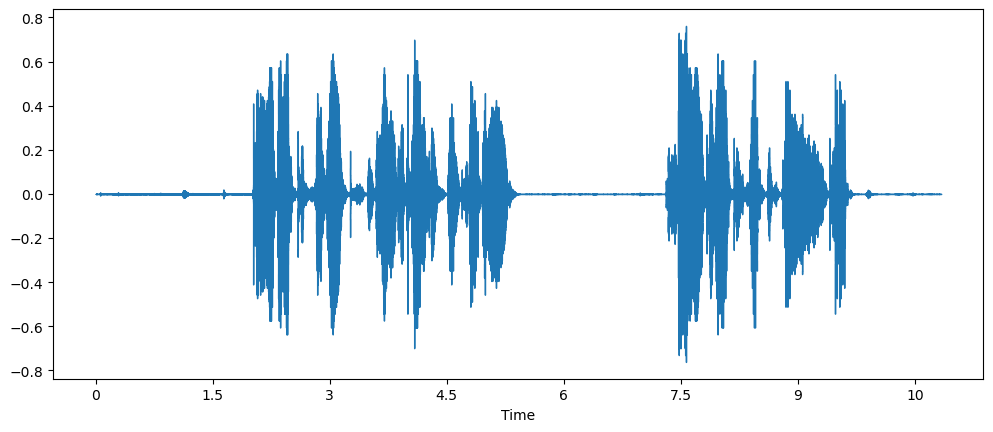

In [9]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

In [10]:
# Resampling

from datasets import Audio
minds = minds.cast_column("audio", Audio(sampling_rate=16000))

minds[0]

{'path': '/home/nitin/.cache/huggingface/datasets/downloads/extracted/587962313ce21a6a8111a65727f66266aa27e7ff07ccaed1fb76aef0c8e25fb1/en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav',
 'audio': {'path': '/home/nitin/.cache/huggingface/datasets/downloads/extracted/587962313ce21a6a8111a65727f66266aa27e7ff07ccaed1fb76aef0c8e25fb1/en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav',
  'array': array([ 1.70562416e-05,  2.18727451e-04,  2.28099874e-04, ...,
          3.43842403e-05, -5.96364771e-06, -1.76846661e-05], shape=(173398,)),
  'sampling_rate': 16000},
 'transcription': 'I would like to set up a joint account with my partner',
 'intent_class': 11}

In [11]:
# Filtering
MAX_DURATION_IN_SECONDS = 20.0


def is_audio_length_in_range(input_length):
    return input_length < MAX_DURATION_IN_SECONDS

# use librosa to get example's duration from the audio file
new_column = [librosa.get_duration(path=x) for x in minds["path"]]
minds = minds.add_column("duration", new_column)

# use 🤗 Datasets' `filter` method to apply the filtering function
minds = minds.filter(is_audio_length_in_range, input_columns=["duration"])

# remove the temporary helper column
minds = minds.remove_columns(["duration"])
minds

Filter:   0%|          | 0/563 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 533
})

In [12]:
from transformers import WhisperFeatureExtractor

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

def prepare_dataset(example):
    audio = example["audio"]
    features = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"], padding=True
    )
    return features

minds = minds.map(prepare_dataset)

Map:   0%|          | 0/533 [00:00<?, ? examples/s]

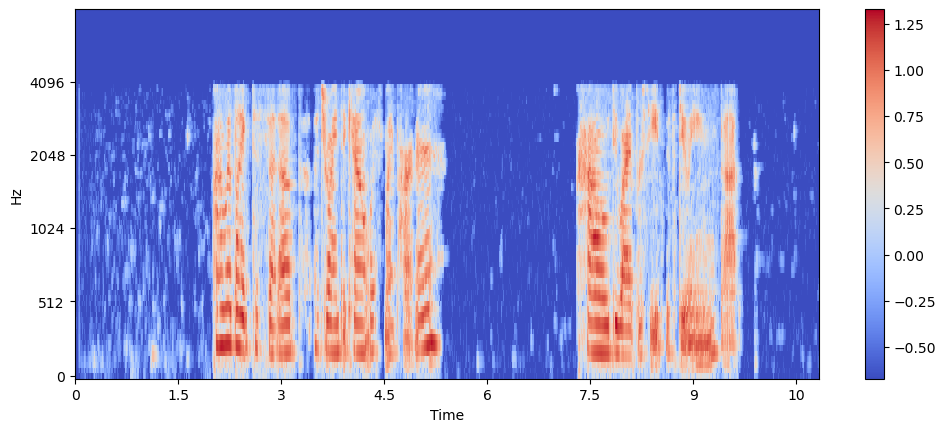

In [13]:
import numpy as np

example = minds[0]
input_features = example["input_features"]

plt.figure().set_figwidth(12)
librosa.display.specshow(
    np.asarray(input_features[0]),
    x_axis="time",
    y_axis="mel",
    sr=feature_extractor.sampling_rate,
    hop_length=feature_extractor.hop_length,
)
plt.colorbar()

In [20]:
# Streaming datasets

gigaspeech = load_dataset("speechcolab/gigaspeech", "xs", streaming=True, trust_remote_code=True)
audio = next(iter(gigaspeech["train"]))

from IPython.display import Audio

Audio(data=audio["audio"]["array"], rate=audio["audio"]["sampling_rate"])


In [21]:
gigaspeech_head = gigaspeech["train"].take(2)
list(gigaspeech_head)

[{'segment_id': 'YOU0000000315_S0000660',
  'speaker': 'N/A',
  'text': "AS THEY'RE LEAVING <COMMA> CAN KASH PULL ZAHRA ASIDE REALLY QUICKLY <QUESTIONMARK>",
  'audio': {'path': 'xs_chunks_0000/YOU0000000315_S0000660.wav',
   'array': array([0.0005188 , 0.00085449, 0.00012207, ..., 0.00125122, 0.00076294,
          0.00036621], shape=(50880,)),
   'sampling_rate': 16000},
  'begin_time': 2941.89,
  'end_time': 2945.07,
  'audio_id': 'YOU0000000315',
  'title': 'Return to Vasselheim | Critical Role: VOX MACHINA | Episode 43',
  'url': 'https://www.youtube.com/watch?v=zr2n1fLVasU',
  'source': 2,
  'category': 24,
  'original_full_path': 'audio/youtube/P0004/YOU0000000315.opus'},
 {'segment_id': 'AUD0000001043_S0000775',
  'speaker': 'N/A',
  'text': 'SIX TOMATOES <PERIOD>',
  'audio': {'path': 'xs_chunks_0000/AUD0000001043_S0000775.wav',
   'array': array([ 1.43432617e-03,  1.37329102e-03,  1.31225586e-03, ...,
          -6.10351562e-05, -1.22070312e-04, -1.83105469e-04], shape=(20800,)